# **Diabetic Retinopathy Classification & Explainability Notebook**  
### *Intro to Artificial Intelligence — Model Development & XAI Pipeline*

### **Model:** EfficientNet-B4  

**Author:** Smridhi Patwari  
**Andrew ID:** smridhip  
**Course:** Introduction to AI / Machine Learning  
**Institution:** Carnegie Mellon University  
**Date:** Fall 2025  

In [1]:
!pip install -q wandb grad-cam lime scikit-image seaborn

In [2]:

# 2) Imports & Global Config

import os
import time
import random
import numpy as np
# Ensure numpy is available and check version compatibility
try:
    assert np is not None, "NumPy is not available"
    np_version = np.__version__
    print(f"✓ NumPy version: {np_version}")
    
    # Check for NumPy 2.x compatibility issues with torchvision
    if np_version.startswith('2.'):
        print("⚠ Warning: NumPy 2.x detected. Some PyTorch/torchvision versions may have compatibility issues.")
        print("  If you encounter 'Numpy is not available' errors, try: pip install 'numpy<2'")
        print("  Or upgrade torchvision: pip install --upgrade torchvision")
except (ImportError, AssertionError) as e:
    print(f" NumPy import error: {e}")
    print("Please install numpy: pip install numpy")
    raise

import pandas as pd
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import models, transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score

import wandb
from dotenv import load_dotenv
from tqdm import tqdm

# Grad-CAM++
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# LIME
from lime import lime_image
from skimage.segmentation import mark_boundaries
from skimage.segmentation import slic

warnings.filterwarnings("ignore")

# Device selection (prioritize MPS for Apple Silicon, then CUDA, then CPU)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device: CUDA")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    # Note: MPS doesn't have manual_seed, but torch.manual_seed works for MPS

set_seed(42)


✓ NumPy version: 1.26.4
Using device: MPS (Apple Silicon GPU)


In [4]:
# 3) Hyperparameters & Paths

# Data paths (local setup for MacBook Pro)
# Commented out Google Drive mounting for local training
# try:
#     from google.colab import drive
#     drive.mount('/content/drive')
#     DATA_DIR = "/content/drive/MyDrive/RetinXplain/dr-data/aptos"  # Adjust path
# except:
#     DATA_DIR = "./data/aptos"  # Local path

# Use local data folder (notebook is in Notebooks/, data is in project root)
# Path relative to notebook location: go up one level (../) to project root, then into data/aptos
DATA_DIR = "../data/aptos"  # Relative path from Notebooks/ to project root/data/aptos

TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
VALID_CSV = os.path.join(DATA_DIR, "valid.csv")
TRAIN_IMAGES_DIR = os.path.join(DATA_DIR, "train_images")
VAL_IMAGES_DIR = os.path.join(DATA_DIR, "val_images")

# Image configuration
IMG_SIZE = 380 
NUM_EPOCHS = 30
BATCH_SIZE = 32
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

# Focal Loss parameters
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = None  # Can be set to per-class weights if needed

# Class names for 5-class DR classification
CLASS_NAMES = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR"
}

# Model save path (local - models folder in project root)
MODEL_DIR = "../models"  # Relative path from Notebooks/ to project root/models
os.makedirs(MODEL_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(MODEL_DIR, "efficientnet_b4_best.pt")

print(f"Data directory: {DATA_DIR}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Number of epochs: {NUM_EPOCHS}")

Data directory: ../data/aptos
Image size: 380x380
Batch size: 32
Number of epochs: 30


In [6]:
class SmartFundusCrop:
    def __call__(self, img):
        np_img = np.array(img)
        gray = cv2.cvtColor(np_img, cv2.COLOR_RGB2GRAY)
        _, thresh = cv2.threshold(gray, 5, 255, cv2.THRESH_BINARY)
        coords = cv2.findNonZero(thresh)
        if coords is None:
            return img
        x, y, w, h = cv2.boundingRect(coords)
        cropped = np_img[y:y+h, x:x+w]
        h2, w2 = cropped.shape[:2]
        side = int(min(w2, h2) * 0.95)
        cx, cy = w2 // 2, h2 // 2
        square = cropped[cy-side//2:cy+side//2, cx-side//2:cx+side//2]
        return Image.fromarray(square)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

IMG_RESIZE = 456
CROP_SIZE = IMG_SIZE

train_transforms = transforms.Compose([
    SmartFundusCrop(),
    transforms.Resize(IMG_RESIZE),
    transforms.RandomResizedCrop(CROP_SIZE, scale=(0.90, 1.0), ratio=(0.95, 1.05)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.10, 0.10, 0.10, 0.03),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transforms = transforms.Compose([
    SmartFundusCrop(),
    transforms.Resize(IMG_RESIZE),
    transforms.CenterCrop(CROP_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Transforms with SmartFundusCrop ready.")

Transforms with SmartFundusCrop ready.


In [9]:
class DRDataset(Dataset):
    """Diabetic Retinopathy Dataset for 5-class classification."""
    
    def __init__(self, csv_path_or_df, images_dir, transform=None):
        """
        Args:
            csv_path_or_df: Path to CSV file OR pandas DataFrame with columns: id_code, diagnosis
            images_dir: Directory containing images
            transform: Optional transform to apply to images
        """
        # Accept either CSV path or DataFrame
        if isinstance(csv_path_or_df, pd.DataFrame):
            self.df = csv_path_or_df.copy()
        else:
            self.df = pd.read_csv(csv_path_or_df)
        
        self.images_dir = images_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_id = str(self.df.iloc[idx]['id_code'])
        label = int(self.df.iloc[idx]['diagnosis'])
        
        # Try .png first, then .jpg
        png_path = os.path.join(self.images_dir, f"{img_id}.png")
        jpg_path = os.path.join(self.images_dir, f"{img_id}.jpg")
        
        if os.path.exists(png_path):
            img_path = png_path
        elif os.path.exists(jpg_path):
            img_path = jpg_path
        else:
            raise FileNotFoundError(f"Image not found: {img_id} (tried both .png and .jpg)")
        
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, label, img_id

print("Dataset class defined!")

Dataset class defined!


In [11]:
def get_dataloaders():
    """Build and return train/val dataloaders with class weights using pre-split CSVs."""
    print("=" * 60)
    print("Starting get_dataloaders()...")
    print("=" * 60)
    
    # Load train and validation CSVs (already split and clean)
    print("Loading train CSV...")
    train_df = pd.read_csv(TRAIN_CSV)
    print(f"Loaded {len(train_df)} training samples")
    
    print("Loading validation CSV...")
    val_df = pd.read_csv(VALID_CSV)
    print(f"Loaded {len(val_df)} validation samples")
    
    # Calculate class weights from training set for weighted sampling
    print("Calculating class weights from training set...")
    class_counts = train_df['diagnosis'].value_counts().sort_index()
    class_weights = 1.0 / class_counts
    class_weights = class_weights / class_weights.sum() * len(class_weights)
    class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32)
    
    # Create datasets directly from CSVs (dataset is clean, no filtering needed)
    print("Creating datasets...")
    train_dataset = DRDataset(TRAIN_CSV, TRAIN_IMAGES_DIR, transform=train_transforms)
    val_dataset = DRDataset(VALID_CSV, VAL_IMAGES_DIR, transform=val_transforms)
    
    # Create sample weights for WeightedRandomSampler
    train_labels = train_df['diagnosis'].values
    sample_weights = [class_weights[label] for label in train_labels]
    sample_weights = torch.DoubleTensor(sample_weights)
    
    train_sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    
    # Create data loaders
    print("Creating data loaders...")
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=train_sampler,
        num_workers=0,
        pin_memory=True if device.type == "cuda" else False
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=True if device.type == "cuda" else False
    )
    
    print(f"Train samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Class distribution:\n{class_counts}")
    print("=" * 60)
    print("✓ get_dataloaders() completed successfully!")
    print("=" * 60)
    
    return train_loader, val_loader, class_counts, class_weights_tensor

✓ Data visualization utilities defined!
  - denorm(img_tensor): Denormalize ImageNet-normalized images
  - show_batch(images, labels, n, ncols): Display a batch of images with labels
Starting get_dataloaders()...
Loading train CSV...
Loaded 2930 training samples
Loading validation CSV...
Loaded 366 validation samples
Calculating class weights from training set...
Creating datasets...
Creating data loaders...
Train samples: 2930
Validation samples: 366
Class distribution:
diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64
✓ get_dataloaders() completed successfully!

Training batch sample:


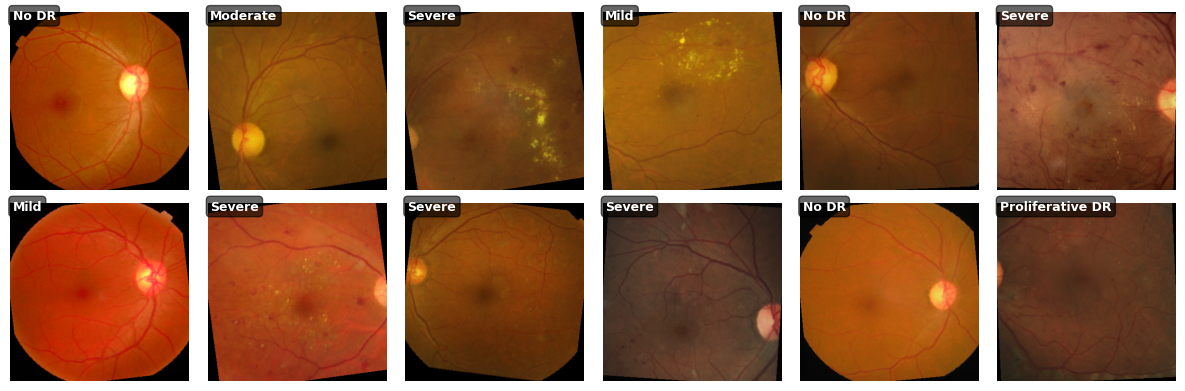


Validation batch sample:


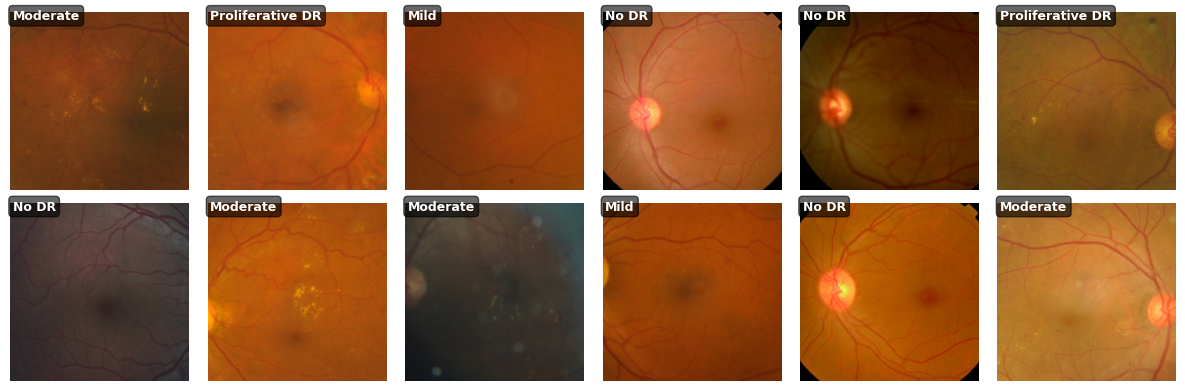

In [12]:
# 4b) Data Visualization Utilities

def denorm(img_tensor):
    """
    Undo ImageNet normalization for visualization.
    
    Args:
        img_tensor: Tensor of shape [C, H, W] or [B, C, H, W]
    
    Returns:
        Denormalized tensor in same shape
    """
    if img_tensor.ndim == 3:
        # single image: [C, H, W]
        mean = torch.tensor(IMAGENET_MEAN, device=img_tensor.device).view(3, 1, 1)
        std = torch.tensor(IMAGENET_STD, device=img_tensor.device).view(3, 1, 1)
    elif img_tensor.ndim == 4:
        # batch: [B, C, H, W]
        mean = torch.tensor(IMAGENET_MEAN, device=img_tensor.device).view(1, 3, 1, 1)
        std = torch.tensor(IMAGENET_STD, device=img_tensor.device).view(1, 3, 1, 1)
    else:
        raise ValueError(f"Unsupported tensor shape for denorm: {img_tensor.shape}")
    return img_tensor * std + mean


def show_batch(images, labels, n=24, ncols=6):
    """
    Display a batch of images with their labels.
    
    Args:
        images: Tensor of images [B, C, H, W] (can be on any device)
        labels: Tensor of labels [B] (can be on any device)
        n: Number of images to display (default: 24)
        ncols: Number of columns in the grid (default: 6)
    """
    # Ensure images and labels are on CPU for visualization
    if isinstance(images, torch.Tensor):
        images = images.cpu()
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu()
    
    n = min(n, len(images))
    nrows = int(np.ceil(n / ncols))
    
    # Use square figsize that scales with grid dimensions to preserve aspect ratio
    fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows))
    
    # Convert axes to a flat list for easier indexing
    if nrows == 1 and ncols == 1:
        axes_list = [axes]
    elif nrows == 1:
        axes_list = list(axes) if hasattr(axes, '__iter__') else [axes]
    elif ncols == 1:
        axes_list = list(axes.flatten()) if hasattr(axes, 'flatten') else [axes]
    else:
        axes_list = list(axes.flatten())
    
    for i in range(n):
        ax = axes_list[i]
        
        # Denormalize and convert to numpy
        img = denorm(images[i])
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        ax.imshow(img)
        ax.set_aspect("equal")  # Preserve 1:1 aspect ratio so fundus images appear round
        ax.axis('off')
        
        label_text = CLASS_NAMES[int(labels[i])]
        ax.text(
            5, 15, label_text,
            color='white', fontsize=9, weight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.6)
        )
    
    # Hide unused subplots
    for i in range(n, len(axes_list)):
        axes_list[i].axis('off')
    
    plt.tight_layout()
    plt.show()


print("✓ Data visualization utilities defined!")
print("  - denorm(img_tensor): Denormalize ImageNet-normalized images")
print("  - show_batch(images, labels, n, ncols): Display a batch of images with labels")

#Test visualization (uncomment to run after get_dataloaders is defined)
train_loader, val_loader, _, _ = get_dataloaders()

# Visualize a batch from training set
print("\nTraining batch sample:")
inputs, labels, img_ids = next(iter(train_loader))
show_batch(inputs, labels, n=12, ncols=6)

# Visualize a batch from validation set  
print("\nValidation batch sample:")
val_inputs, val_labels, val_img_ids = next(iter(val_loader))
show_batch(val_inputs, val_labels, n=12, ncols=6)


In [14]:
# 8) Loss, Optimizer, Scheduler

# Focal Loss implementation
class FocalLoss(nn.Module):
    """Focal Loss for multi-class classification."""
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

print("FocalLoss class defined!")


FocalLoss class defined!


In [ ]:
# 9) wandb Setup

# Helper function to setup wandb
def setup_wandb():
    # Initialize wandb with settings that disable problematic Jupyter hooks
    wandb.init(
        project="retinexplain-efficientnet-b4",
        config={
            "learning_rate": LEARNING_RATE,
            "batch_size": BATCH_SIZE,
            "epochs": NUM_EPOCHS,
            "weight_decay": WEIGHT_DECAY,
            "focal_gamma": FOCAL_GAMMA,
            "image_size": IMG_SIZE,
            "model": "EfficientNet-B4",
            "num_classes": 5,
            "optimizer": "AdamW",
            "scheduler": "CosineAnnealingLR"
        },
        settings=wandb.Settings(
            _disable_stats=True,
            _disable_meta=True,
        )
    )

print("wandb setup function defined!")


In [16]:
# 10) Early Stopping & Training & Validation Functions

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        """
        patience: how many epochs with no improvement before stopping
        min_delta: minimum change in monitored metric to be considered an improvement
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, current_score):
        if self.best_score is None or current_score > self.best_score + self.min_delta:
            self.best_score = current_score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


def train_one_epoch(model, loader, optimizer, loss_fn, device, scheduler=None, epoch=None):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    # Match cleaned notebook exactly - simple tqdm wrapper
    loop = tqdm(loader, desc="train", leave=False)
    for images, labels, _ in loop:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = np.mean(np.array(all_preds) == np.array(all_labels))
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return epoch_loss, epoch_acc, epoch_f1


def validate(model, loader, loss_fn, device):
    """Validate the model."""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    # Match cleaned notebook exactly - simple tqdm wrapper
    loop = tqdm(loader, desc="  val", leave=False)
    with torch.no_grad():
        for images, labels, _ in loop:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = np.mean(np.array(all_preds) == np.array(all_labels))
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return epoch_loss, epoch_acc, epoch_f1, all_preds, all_labels


In [17]:
# 11) Modular Functions for Data, Model, Training, and Evaluation


def build_model(num_classes: int = 5) -> nn.Module:
    """Build and return EfficientNet-B4 model for classification."""
    # Load pretrained EfficientNet-B4
    
    model = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
    
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    
    # Move model to device
    model = model.to(device)
    
    print(f"Model loaded: EfficientNet-B4 with {num_classes} output classes")
    print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    return model


def train_and_validate(model, train_loader, val_loader, class_weights_tensor):
    """Train and validate the model with early stopping."""
    # Loss function (Focal Loss without alpha - using WeightedRandomSampler for balancing)
    criterion = FocalLoss(
        alpha=None,
        gamma=FOCAL_GAMMA,
        reduction='mean'
    )
    
    # Optimizer
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=NUM_EPOCHS,
        eta_min=1e-6
    )
    
    # Early stopping
    early_stopper = EarlyStopping(patience=5, min_delta=1e-3)
    
    # Training history
    best_val_f1 = 0.0
    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': []
    }
    
    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print("-" * 50)
        
        # Training
        train_loss, train_acc, train_f1 = train_one_epoch(
            model, train_loader, optimizer, criterion, device, scheduler, epoch
        )
        
        # Validation
        val_loss, val_acc, val_f1, _, _ = validate(
            model, val_loader, criterion, device
        )
        
        # Step scheduler
        scheduler.step()
        
        # Log to wandb
        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'train_f1': train_f1,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_f1': val_f1,
            'learning_rate': scheduler.get_last_lr()[0]
        })
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        # Save best model based on validation F1
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(f"✓ New best model saved! (Val F1: {val_f1:.4f})")
        
        print(f"Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}")
        print(f"Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")
        
        # Early stopping check
        early_stopper.step(val_f1)
        if early_stopper.should_stop:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break
    
    print("\nTraining completed!")
    print(f"Best validation F1: {best_val_f1:.4f}")
    
    # Load best model
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    
    return model, history


print("Modular functions defined!")


Modular functions defined!


In [ ]:
# 12) Train the Model

load_dotenv()
os.environ["WANDB_API_KEY"] = os.getenv("WANDB_API_KEY")

# Setup wandb (will use API key from environment)
setup_wandb()

# Get data loaders
train_loader, val_loader, class_counts, class_weights_tensor = get_dataloaders()

# Build model
model = build_model(num_classes=5)

# Train and validate
model, history = train_and_validate(model, train_loader, val_loader, class_weights_tensor)

# Finish wandb run
wandb.finish()

print("\n✓ Training completed!")
print(f"Best model saved to: {BEST_MODEL_PATH}")

In [24]:


def load_model_from_checkpoint(model_path=None):
    """
    Load a saved model from checkpoint.
    
    Args:
        model_path: Path to saved model. If None, uses BEST_MODEL_PATH
    
    Returns:
        model: Loaded and evaluated model
        val_loader: Validation data loader
    """
    if model_path is None:
        model_path = BEST_MODEL_PATH
    
    print(f"Loading model from: {model_path}")
    
    # Build model
    model = build_model(num_classes=5)
    
    # Load weights
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    print("✓ Model loaded successfully!")
    
    # Get validation loader
    print("Loading validation data...")
    _, val_loader, _, _ = get_dataloaders()
    
    return model, val_loader


def generate_confusion_matrix(model, val_loader):
    """
    Generate and display confusion matrix without wandb.
    Works with a loaded model - no training required.
    """
    criterion = FocalLoss(alpha=None, gamma=FOCAL_GAMMA, reduction='mean')
    val_loss, val_acc, val_f1, y_pred, y_true = validate(model, val_loader, criterion, device)
    
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    cm_percent = np.round(cm_percent, 2)
    report = classification_report(y_true, y_pred, target_names=[CLASS_NAMES[i] for i in range(5)], digits=3)
    
    print("=" * 60)
    print("CONFUSION MATRIX RESULTS")
    print("=" * 60)
    print(f"Accuracy: {val_acc:.4f} | F1 Score: {val_f1:.4f}")
    print(f"\nConfusion Matrix (Counts):")
    print(cm)
    print(f"\nConfusion Matrix (Percentages):")
    print(cm_percent)
    print(f"\nClassification Report:")
    print(report)
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[CLASS_NAMES[i] for i in range(5)],
                yticklabels=[CLASS_NAMES[i] for i in range(5)], ax=axes[0])
    axes[0].set_title('Confusion Matrix (Counts) - EfficientNet-B4 DR Classification')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    
    sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=[CLASS_NAMES[i] for i in range(5)],
                yticklabels=[CLASS_NAMES[i] for i in range(5)], ax=axes[1])
    axes[1].set_title('Confusion Matrix (Percentages) - EfficientNet-B4 DR Classification')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.show()
    
    metrics = {
        'accuracy': val_acc,
        'f1_score': val_f1,
        'loss': val_loss,
        'confusion_matrix': cm,
        'confusion_matrix_percent': cm_percent
    }
    
    return cm, cm_percent, metrics


def setup_gradcam(model):
    """
    Setup Grad-CAM++ for the model.
    Target layer: last feature block in EfficientNet-B4.
    """
    # Ensure target layer has gradients enabled
    for param in model.features[-1].parameters():
        param.requires_grad = True
    
    # Target layer: last feature block in EfficientNet-B4
    target_layers = [model.features[-1]]
    
    # Initialize Grad-CAM++
    cam = GradCAMPlusPlus(model=model, target_layers=target_layers)
    return cam


def generate_gradcam(model, cam, img_tensor, target_class=None):
    """
    Generate Grad-CAM++ heatmap and overlay.
    
    Args:
        model: Trained model
        cam: GradCAMPlusPlus instance
        img_tensor: Image tensor (1, 3, H, W) on device
        target_class: Class to explain. If None, uses predicted class.
    
    Returns:
        grayscale_cam: Heatmap array
        overlay: Image with heatmap overlay
        img_np: Denormalized original image
    """
    # Get prediction if target_class not specified
    if target_class is None:
        with torch.no_grad():
            logits = model(img_tensor)
            target_class = logits.argmax(1).item()
    
    # Generate CAM
    targets = [ClassifierOutputTarget(target_class)]
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]
    
    # Denormalize image for visualization
    img_np = img_tensor[0].cpu().permute(1, 2, 0).numpy()
    mean = np.array(IMAGENET_MEAN).reshape(1, 1, 3)
    std = np.array(IMAGENET_STD).reshape(1, 1, 3)
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1)
    
    # Create overlay
    overlay = show_cam_on_image(img_np.astype(np.float32), grayscale_cam, use_rgb=True, image_weight=0.6)
    
    return grayscale_cam, overlay, img_np


def setup_lime(model):
    explainer = lime_image.LimeImageExplainer()

    def lime_predict_fn(images_np):
        model.eval()
        batch_tensors = []
        for img in images_np:
            if img.max() > 1.0:
                img = img / 255.0
            img_uint8 = (img * 255).astype(np.uint8)
            pil_img = Image.fromarray(img_uint8)
            img_tensor = val_transforms(pil_img)
            batch_tensors.append(img_tensor)

        batch = torch.stack(batch_tensors).to(device)

        with torch.no_grad():
            logits = model(batch)
            probs = F.softmax(logits, dim=1).cpu().numpy()

        return probs

    return explainer, lime_predict_fn


def generate_lime(img_np, explainer, lime_predict_fn, pred_label,
                  num_features=6, num_samples=1000):
    def segmentation_fn(x):
        return slic(x, n_segments=150, compactness=10, sigma=1)

    explanation = explainer.explain_instance(
        img_np,
        lime_predict_fn,
        top_labels=5,
        num_samples=num_samples,
        hide_color=0,
        segmentation_fn=segmentation_fn,
    )

    temp, mask = explanation.get_image_and_mask(
        pred_label,
        positive_only=True,
        num_features=num_features,
        hide_rest=False,
    )

    temp_vis = temp.astype(np.float32)
    if temp_vis.max() > 1.0:
        temp_vis /= 255.0

    lime_overlay = mark_boundaries(temp_vis, mask)
    return lime_overlay



print("✓ Evaluation functions defined!")
print("  - load_model_from_checkpoint(model_path)")
print("  - generate_confusion_matrix(model, val_loader)")
print("  - setup_gradcam(model)")
print("  - generate_gradcam(model, cam, img_tensor)")
print("  - setup_lime(model)")
print("  - generate_lime(img_np, explainer, lime_predict_fn, pred_label)")



✓ Evaluation functions defined!
  - load_model_from_checkpoint(model_path)
  - generate_confusion_matrix(model, val_loader)
  - setup_gradcam(model)
  - generate_gradcam(model, cam, img_tensor)
  - setup_lime(model)
  - generate_lime(img_np, explainer, lime_predict_fn, pred_label)


In [19]:
# 12a) Load Model from Saved Weights

# Load the saved model and validation data
model, val_loader = load_model_from_checkpoint()


Loading model from: ../models/efficientnet_b4_best.pt
Model loaded: EfficientNet-B4 with 5 output classes
Total parameters: 17,557,581
✓ Model loaded successfully!
Loading validation data...
Starting get_dataloaders()...
Loading train CSV...
Loaded 2930 training samples
Loading validation CSV...
Loaded 366 validation samples
Calculating class weights from training set...
Creating datasets...
Creating data loaders...
Train samples: 2930
Validation samples: 366
Class distribution:
diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64
✓ get_dataloaders() completed successfully!


CONFUSION MATRIX RESULTS
Accuracy: 0.7049 | F1 Score: 0.7175

Confusion Matrix (Counts):
[[162  10   0   0   0]
 [  1  24  11   1   3]
 [  3  13  54  21  13]
 [  0   2   7   9   4]
 [  0   3   6  10   9]]

Confusion Matrix (Percentages):
[[94.19  5.81  0.    0.    0.  ]
 [ 2.5  60.   27.5   2.5   7.5 ]
 [ 2.88 12.5  51.92 20.19 12.5 ]
 [ 0.    9.09 31.82 40.91 18.18]
 [ 0.   10.71 21.43 35.71 32.14]]

Classification Report:
                  precision    recall  f1-score   support

           No DR      0.976     0.942     0.959       172
            Mild      0.462     0.600     0.522        40
        Moderate      0.692     0.519     0.593       104
          Severe      0.220     0.409     0.286        22
Proliferative DR      0.310     0.321     0.316        28

        accuracy                          0.705       366
       macro avg      0.532     0.558     0.535       366
    weighted avg      0.743     0.705     0.717       366



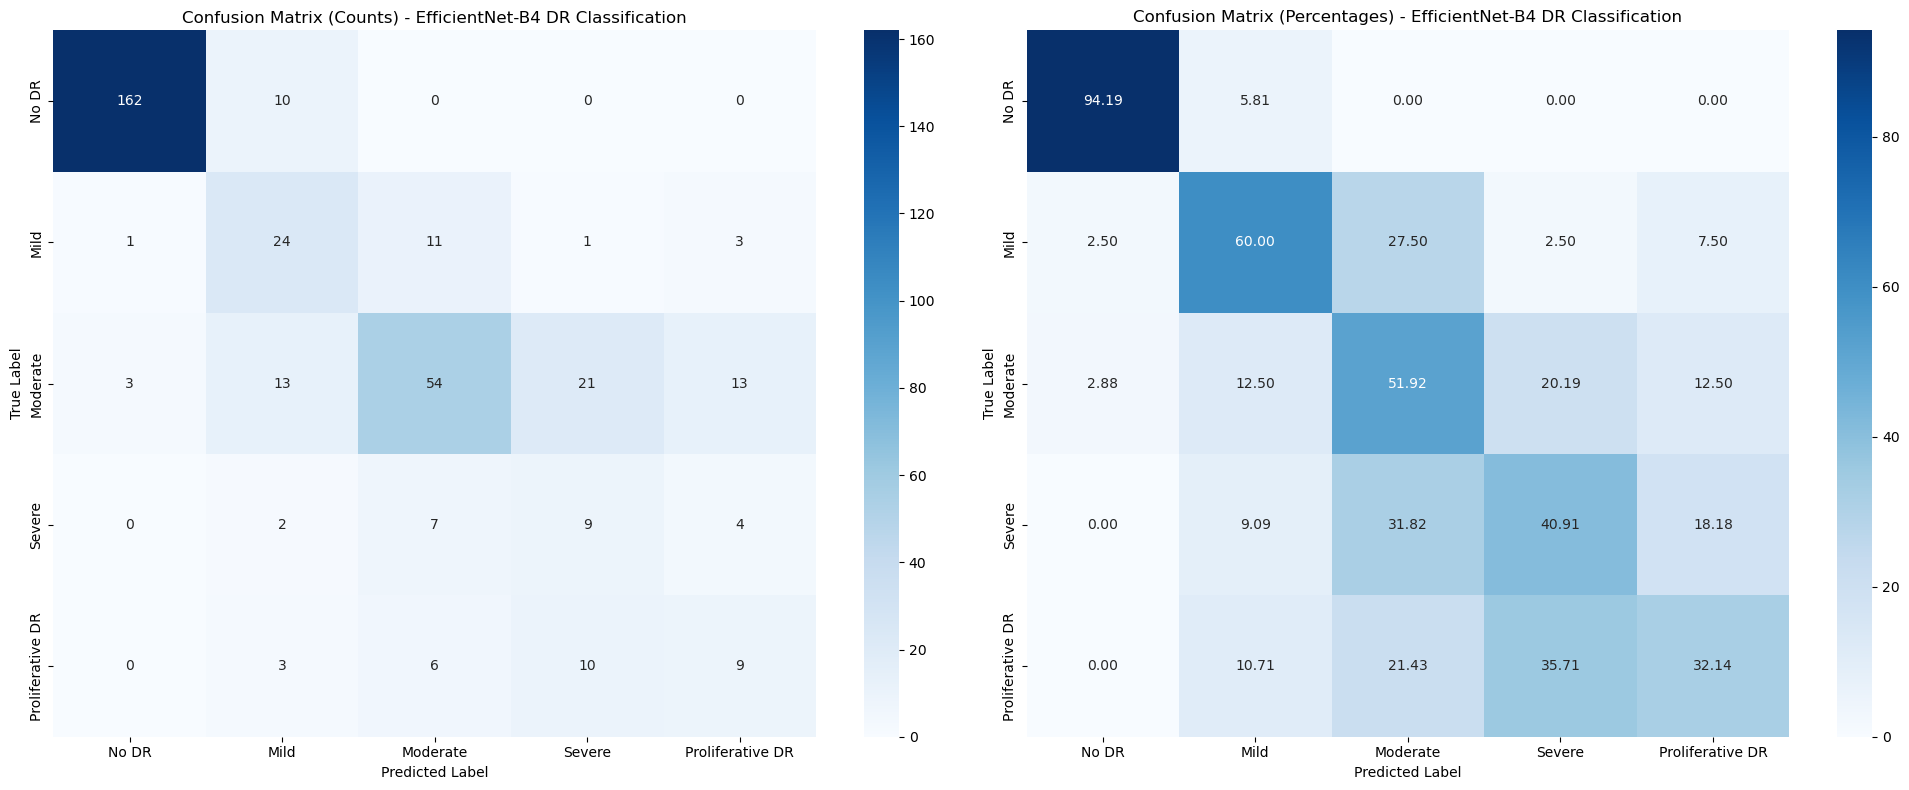

In [20]:
# 12b) Generate and Display Confusion Matrix

# Generate and display confusion matrix
cm, cm_percent, metrics = generate_confusion_matrix(model, val_loader)


GRAD-CAM++ EXPLANATIONS (Original vs Grad-CAM++)


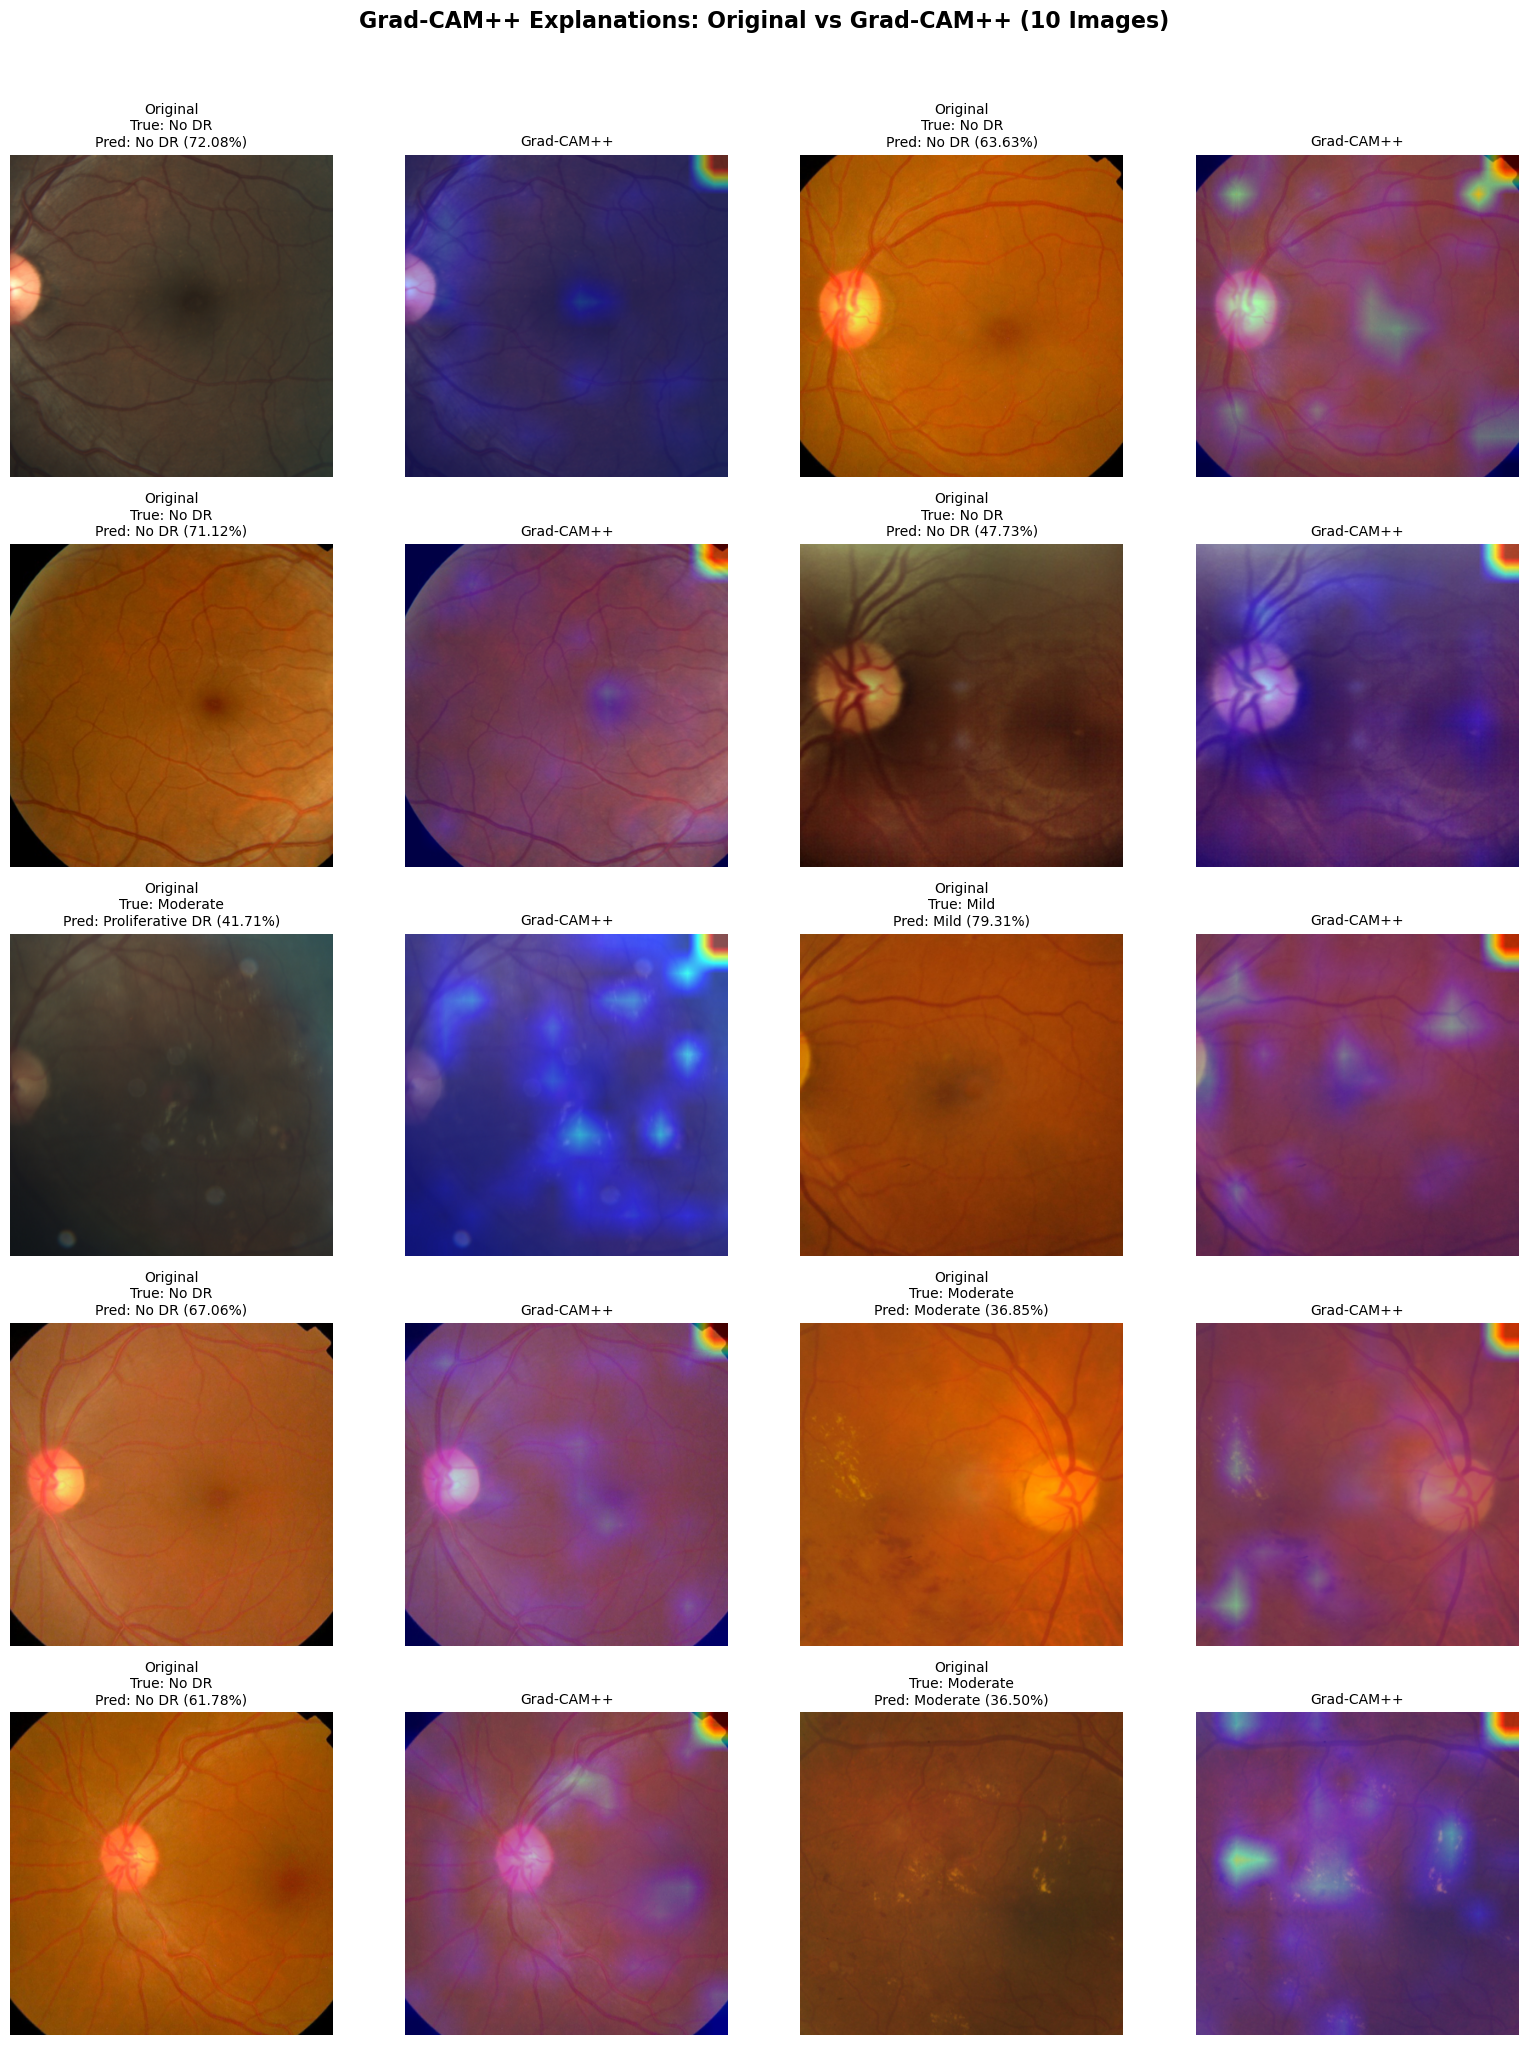


✓ Generated 10 Grad-CAM++ explanations (2 predictions per row)!


In [21]:
# 12c) Generate and Display Grad-CAM++ Explanations (2 predictions per row)

cam = setup_gradcam(model)

# Get 10 random images from validation set
val_images, val_labels, val_ids = next(iter(val_loader))
indices = np.random.choice(len(val_images), size=10, replace=False)

print("=" * 60)
print("GRAD-CAM++ EXPLANATIONS (Original vs Grad-CAM++)")
print("=" * 60)

n_images = len(indices)        # number of predictions
pairs_per_row = 2              # 2 predictions per row
ncols = pairs_per_row * 2      # each prediction = 2 columns (orig + cam)
nrows = int(np.ceil(n_images / pairs_per_row))

fig_gradcam, axes_gradcam = plt.subplots(
    nrows, ncols, figsize=(4 * ncols, 4 * nrows)
)

# Make axes always iterable & flat
if nrows == 1 and ncols == 1:
    axes_flat = [axes_gradcam]
else:
    axes_flat = np.array(axes_gradcam).ravel()

for idx, img_idx in enumerate(indices):
    img_tensor = val_images[img_idx:img_idx+1].to(device)
    true_label = val_labels[img_idx].item()

    with torch.no_grad():
        logits = model(img_tensor)
        pred_label = logits.argmax(1).item()
        confidence = F.softmax(logits, dim=1)[0][pred_label].item()

    heatmap, overlay, original = generate_gradcam(model, cam, img_tensor, pred_label)

    row = idx // pairs_per_row
    col_pair = idx % pairs_per_row
    start_col = row * ncols + col_pair * 2

    # Original image
    ax_orig = axes_flat[start_col]
    ax_orig.imshow(original)
    ax_orig.set_aspect("equal")
    ax_orig.set_title(
        f"Original\nTrue: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]} ({confidence:.2%})",
        fontsize=10
    )
    ax_orig.axis("off")

    # Grad-CAM++ overlay
    ax_cam = axes_flat[start_col + 1]
    ax_cam.imshow(overlay)
    ax_cam.set_aspect("equal")
    ax_cam.set_title("Grad-CAM++", fontsize=10)
    ax_cam.axis("off")

# Hide any unused subplots
used_slots = n_images * 2
total_slots = nrows * ncols
for i in range(used_slots, total_slots):
    axes_flat[i].axis("off")

plt.suptitle(
    "Grad-CAM++ Explanations: Original vs Grad-CAM++ (10 Images)",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

print("\n✓ Generated 10 Grad-CAM++ explanations (2 predictions per row)!")


LIME EXPLANATIONS (Original vs LIME)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

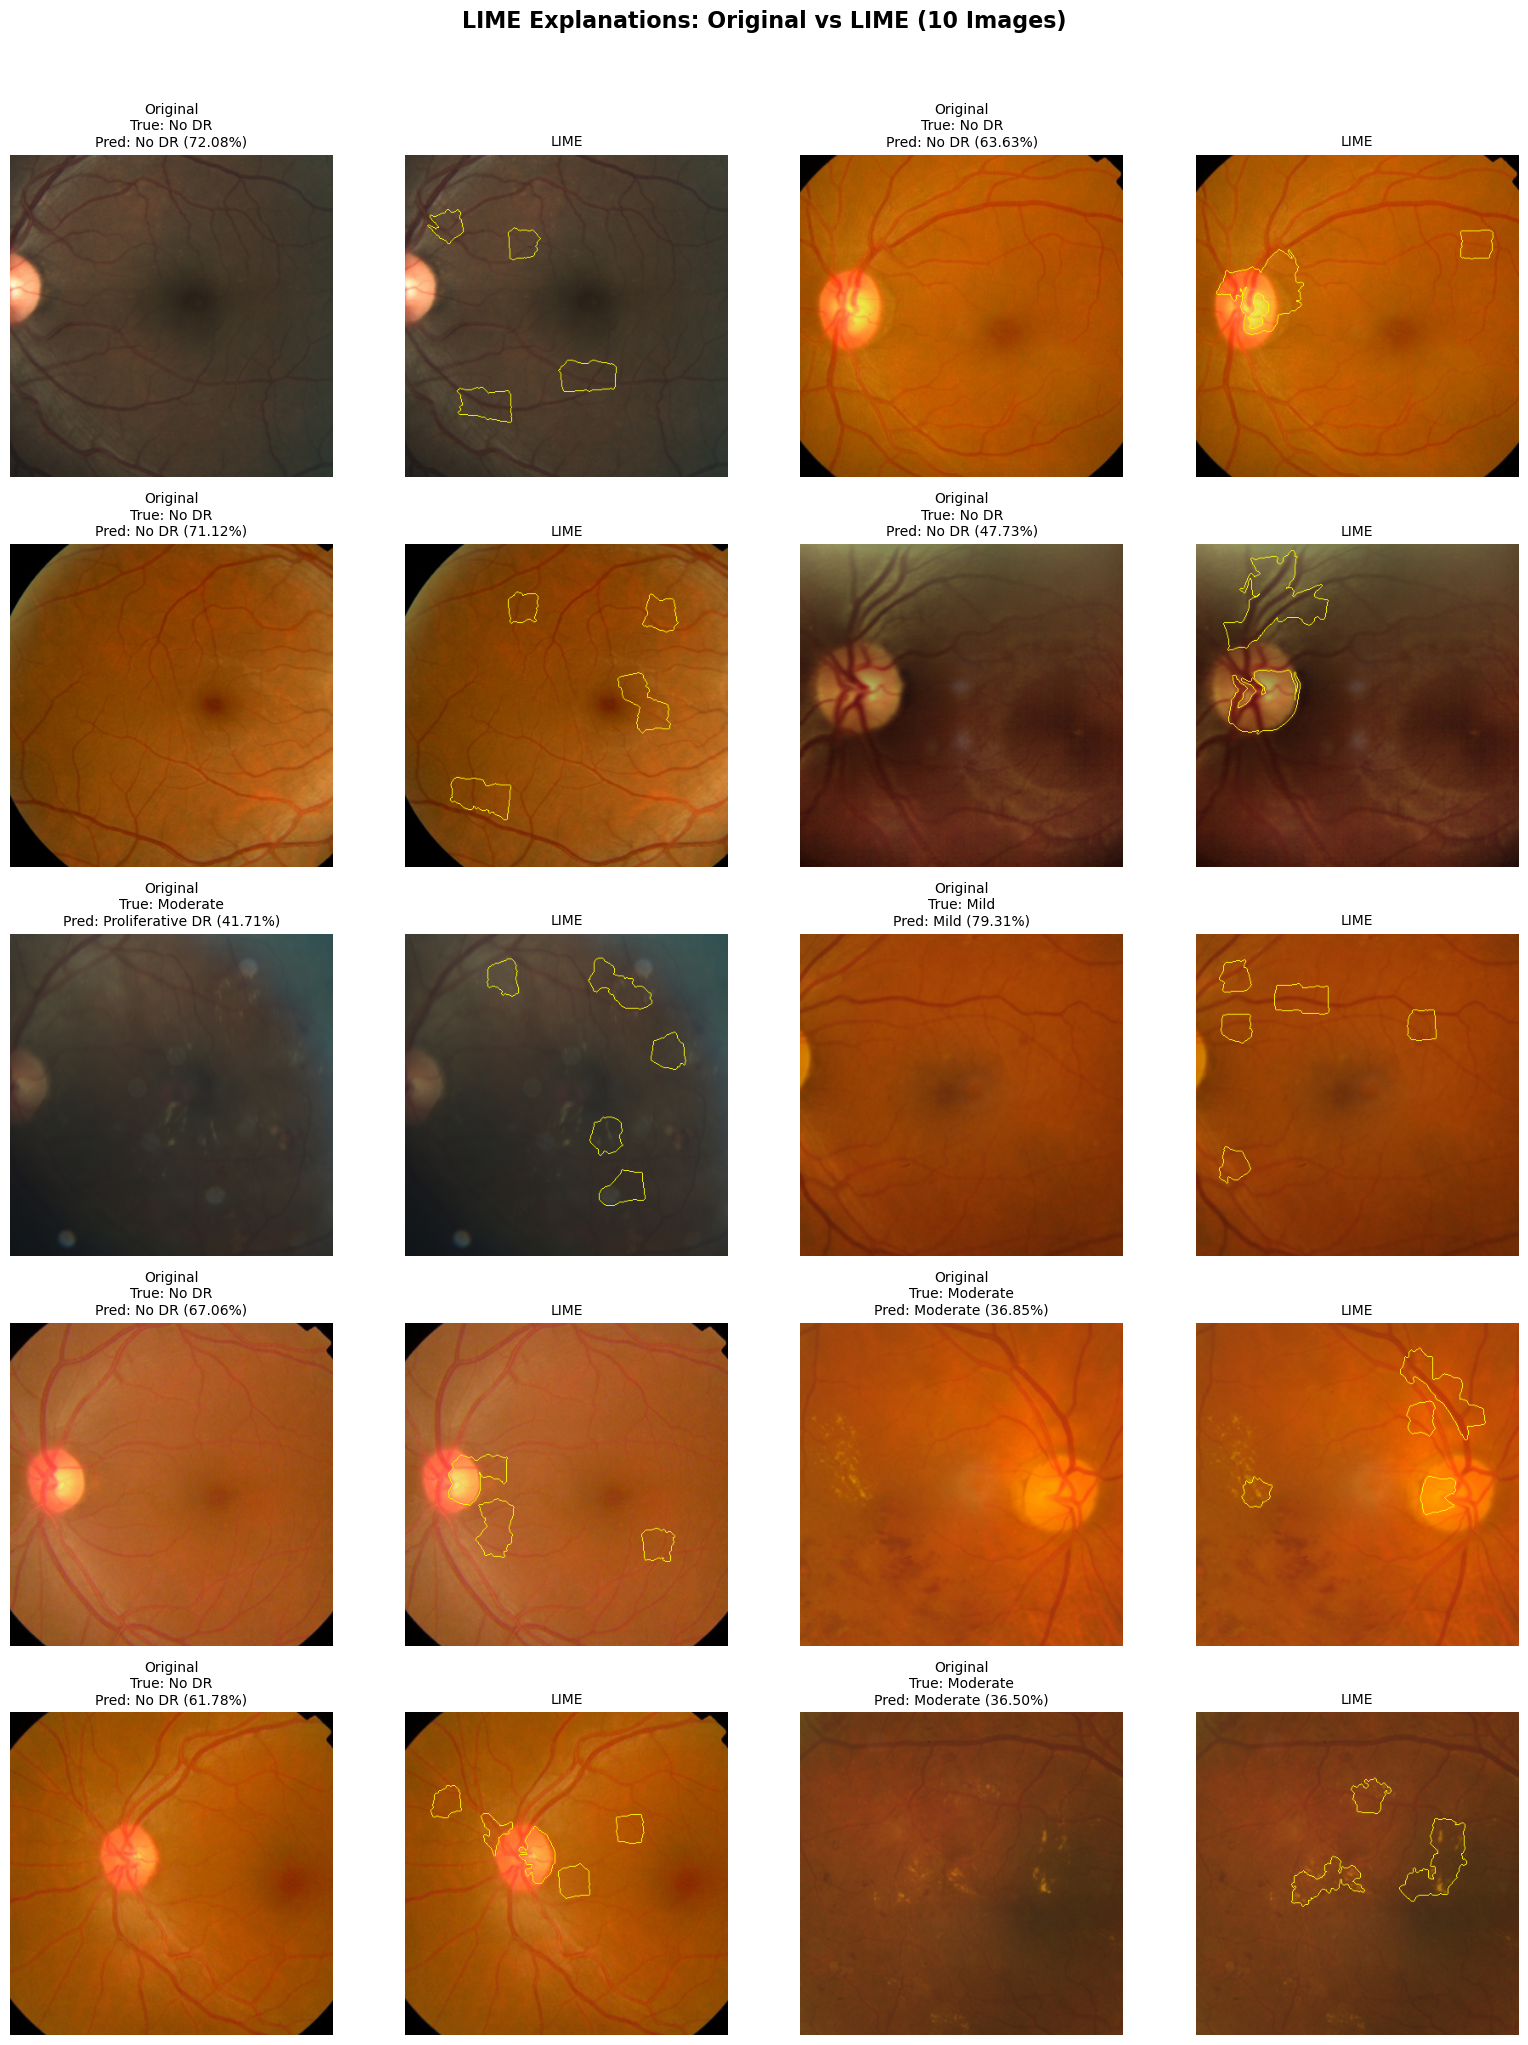


✓ Generated 10 LIME explanations (2 predictions per row)!


In [22]:
## 12d) Generate and Display LIME Explanations (2 predictions per row)

explainer, lime_predict_fn = setup_lime(model)

# Reuse val_images, val_labels, indices from the Grad-CAM cell.
# If running independently, uncomment:
# val_images, val_labels, val_ids = next(iter(val_loader))
# indices = np.random.choice(len(val_images), size=10, replace=False)

print("=" * 60)
print("LIME EXPLANATIONS (Original vs LIME)")
print("=" * 60)

n_images = len(indices)
pairs_per_row = 2          # 2 predictions per row
ncols = pairs_per_row * 2  # each prediction = 2 columns (orig + LIME)
nrows = int(np.ceil(n_images / pairs_per_row))

fig_lime, axes_lime = plt.subplots(
    nrows, ncols, figsize=(4 * ncols, 4 * nrows)
)

# Flatten axes to 1D list
if nrows == 1 and ncols == 1:
    axes_flat = [axes_lime]
else:
    axes_flat = np.array(axes_lime).ravel()

for idx, img_idx in enumerate(indices):
    img_tensor = val_images[img_idx:img_idx+1].to(device)
    true_label = val_labels[img_idx].item()

    with torch.no_grad():
        logits = model(img_tensor)
        pred_label = logits.argmax(1).item()
        confidence = F.softmax(logits, dim=1)[0][pred_label].item()

    # Denormalize to numpy for LIME
    img_np = img_tensor[0].cpu().permute(1, 2, 0).numpy()
    mean = np.array(IMAGENET_MEAN).reshape(1, 1, 3)
    std = np.array(IMAGENET_STD).reshape(1, 1, 3)
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1)

    lime_overlay = generate_lime(img_np, explainer, lime_predict_fn, pred_label)

    row = idx // pairs_per_row
    col_pair = idx % pairs_per_row
    start_col = row * ncols + col_pair * 2

    # Original image
    ax_orig = axes_flat[start_col]
    ax_orig.imshow(img_np)
    ax_orig.set_aspect("equal")
    ax_orig.set_title(
        f"Original\nTrue: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]} ({confidence:.2%})",
        fontsize=10,
    )
    ax_orig.axis("off")

    # LIME overlay
    ax_lime = axes_flat[start_col + 1]
    ax_lime.imshow(lime_overlay)
    ax_lime.set_aspect("equal")
    ax_lime.set_title("LIME", fontsize=10)
    ax_lime.axis("off")

# Hide unused subplots
used_slots = n_images * 2
total_slots = nrows * ncols
for i in range(used_slots, total_slots):
    axes_flat[i].axis("off")

plt.suptitle(
    "LIME Explanations: Original vs LIME (10 Images)",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

print("\n✓ Generated 10 LIME explanations (2 predictions per row)!")


In [ ]:
# 12e) Combined Visualization: Original, Grad-CAM++, LIME

# Generate combined visualizations showing all three methods side by side
print("=" * 60)
print("COMBINED EXPLANATIONS (Original, Grad-CAM++, LIME)")
print("=" * 60)

# 1 prediction per row (each prediction = 3 columns: Original, GradCAM, LIME)
n_images = len(indices)
ncols_per_row = 3  # 1 prediction × 3 columns per prediction = 3 columns
nrows = n_images  # 1 prediction per row

fig_combined, axes_combined = plt.subplots(nrows, ncols_per_row, figsize=(12, 6 * nrows))
axes_combined = axes_combined.flatten()

for idx, img_idx in enumerate(indices):
    img_tensor = val_images[img_idx:img_idx+1].to(device)
    true_label = val_labels[img_idx].item()
    
    with torch.no_grad():
        logits = model(img_tensor)
        pred_label = logits.argmax(1).item()
        confidence = F.softmax(logits, dim=1)[0][pred_label].item()
    
    # Get original image
    img_np = img_tensor[0].cpu().permute(1, 2, 0).numpy()
    mean = np.array(IMAGENET_MEAN).reshape(1, 1, 3)
    std = np.array(IMAGENET_STD).reshape(1, 1, 3)
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1)
    
    # Generate Grad-CAM++
    heatmap, overlay_gradcam, original = generate_gradcam(model, cam, img_tensor, pred_label)
    
    # Generate LIME 
    lime_overlay = generate_lime(img_np, explainer, lime_predict_fn, pred_label)
    
    
    # Calculate position: each prediction takes 3 columns, 1 prediction per row
    row = idx
    start_col = row * ncols_per_row
    
    # Original image
    ax_orig = axes_combined[start_col]
    ax_orig.imshow(original)
    ax_orig.set_aspect("equal")
    ax_orig.set_title(
        f"Original\nTrue: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]} ({confidence:.2%})",
        fontsize=10, fontweight='bold'
    )
    ax_orig.axis('off')
    
    # Grad-CAM++
    ax_gradcam = axes_combined[start_col + 1]
    ax_gradcam.imshow(overlay_gradcam)
    ax_gradcam.set_aspect("equal")
    ax_gradcam.set_title("Grad-CAM++", fontsize=10, fontweight='bold')
    ax_gradcam.axis('off')
    
    # LIME
    ax_lime = axes_combined[start_col + 2]
    ax_lime.imshow(lime_overlay)
    ax_lime.set_aspect("equal")
    ax_lime.set_title("LIME", fontsize=10, fontweight='bold')
    ax_lime.axis('off')
    

# No unused subplots since we have exactly n_images rows with 3 columns each

plt.suptitle('Combined Explanations: Original | Grad-CAM++ | LIME ', 
             fontsize=16, fontweight='bold', y=0.998)
plt.tight_layout()
plt.show()

print("\n✓ Generated combined visualizations for 10 images!")


In [ ]:
# === Compute & Plot ROC–AUC for ResNet50 on Validation Set ===

from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels, _ in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)

        all_labels.append(labels.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

# Stack everything
all_labels = np.concatenate(all_labels)          # shape: [N]
all_probs = np.concatenate(all_probs, axis=0)    # shape: [N, num_classes]

num_classes = len(CLASS_NAMES)

# One-hot / binarize labels for multi-class ROC–AUC
y_true_bin = label_binarize(all_labels, classes=np.arange(num_classes))

# ----- AUC NUMBERS -----
# Per-class AUC
per_class_auc = roc_auc_score(y_true_bin, all_probs, average=None)

# Aggregate AUCs
macro_auc    = roc_auc_score(y_true_bin, all_probs, average="macro")
micro_auc    = roc_auc_score(y_true_bin, all_probs, average="micro")
weighted_auc = roc_auc_score(y_true_bin, all_probs, average="weighted")

print("=== ROC–AUC RESULTS (Validation Set) ===\n")
for i, auc_val in enumerate(per_class_auc):
    print(f"{i} - {CLASS_NAMES[i]:>15}: AUC = {auc_val:.4f}")

print("\nOverall AUCs:")
print(f"Macro AUC    : {macro_auc:.4f}")
print(f"Micro AUC    : {micro_auc:.4f}")
print(f"Weighted AUC : {weighted_auc:.4f}")

# ----- ROC CURVES -----
fpr = {}
tpr = {}
roc_auc = {}

# Per-class ROC
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average ROC (all classes flattened)
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot
plt.figure(figsize=(8, 6))

# Micro-average curve
plt.plot(
    fpr["micro"], tpr["micro"],
    label=f"micro-average ROC (AUC = {roc_auc['micro']:.3f})",
    linewidth=2,
)

# Per-class curves
for i in range(num_classes):
    plt.plot(
        fpr[i], tpr[i],
        linestyle="--",
        label=f"{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.3f})"
    )

# Chance line
plt.plot([0, 1], [0, 1], "k:", label="Chance")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – ResNet50 DR Classification (Validation Set)")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
